In [1]:
from langgraph.types import Send, interrupt, Command
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
import operator
from typing import Optional, List, Annotated
from langchain.messages import HumanMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig

In [2]:
import operator
from typing import Annotated, List, Literal


# --- State ---


class SubgraphState(TypedDict):
    identifier: Optional[str]
    c_messages: Annotated[List[str], operator.add]
    # iterations_remaining: int
    current_iteration: int
    c_result: str


# --- Nodes ---


def node_c(state: SubgraphState):
    current = state.get("current_iteration", 1)

    print("\n--- Node C ---")
    print(f"    iteration : {current}")

    result = f"Result from C (iteration={current})"
    print(f"    produced  : {result}")

    return {
        "c_result": result,
        "current_iteration": current + 1,
        "c_messages": [f"[node_c iter={current}] {result}"],
    }


def node_c_review(state: SubgraphState):
    current = state["current_iteration"]
    result = state["c_result"]

    print("\n--- Node C Review ---")
    print(f"    reviewed  : {result}")
    print("    waiting for human feedback...")

    human_feedback = interrupt(
        f"Review the result and provide feedback: {state['identifier']}"
    )

    approved = human_feedback["approved"]
    print(f"    feedback received: {human_feedback}")

    if approved == 1:
        print(f"    ✅ Approved on iteration {current - 1}")
        return {
            "c_messages": [f"[review iter={current - 1}] Approved — {result}"],
        }
    else:
        print(f"    🔁 Rejected on iteration {current - 1}, looping back")
        return {
            "c_messages": [f"[review iter={current - 1}] Rejected — looping back"],
        }


# --- Conditional Edge ---


def route_after_review(state: SubgraphState) -> Literal["node_c", "__end__"]:
    last_message = state["c_messages"][-1]

    if "Approved" in last_message:
        print("\n→ Routing to END")
        return END
    else:
        print("\n→ Routing back to node_c")
        return "node_c"


# --- Build Graph ---

builder = StateGraph(SubgraphState)

builder.add_node("node_c", node_c)
builder.add_node("node_c_review", node_c_review)

builder.set_entry_point("node_c")
builder.add_edge("node_c", "node_c_review")
builder.add_conditional_edges("node_c_review", route_after_review)

sub_graph = builder.compile()

In [3]:
class OverallState(TypedDict):
    a_context: str
    b_context: Optional[str]
    b_result: Optional[List[str]]
    c_results: Annotated[List[str], operator.add]


def node_a(state: OverallState) -> OverallState:
    print("\n\n----------------------")
    print("Node A")
    print("State:", state)
    print("----------------------\n\n")
    return {"b_context": "Result from A"}


def node_b(state: OverallState) -> OverallState:
    print("\n\n----------------------")
    print("Node b")
    print("State:", state)
    print("----------------------\n\n")
    return {"b_result": ["Result 1 from B", "Result 2 from B"]}


def continue_to_c(state: OverallState):
    print("\n\n----------------------")
    print("Node continue to c")
    print("State:", state)
    print("----------------------\n\n")
    return [Send("execute_c", {"c_context": s}) for s in state["b_result"]]


def execute_c(state: OverallState):
    context = state["c_context"]

    print(f"\n{'=' * 50}")
    print(f"execute_c called with context : '{context}'")
    print(f"{'=' * 50}")

    identifier = context.split(" ")[1]

    result = sub_graph.invoke(
        {
            "identifier": identifier,
            "current_iteration": 1,
            "c_messages": [],
            "c_result": "",
        }
    )

    print("\n  ✅ subgraph done")
    print(f"     final c_result : {result['c_result']}")
    print(f"     total messages : {len(result['c_messages'])}")
    for msg in result["c_messages"]:
        print(f"       • {msg}")

    return {"c_results": [result["c_result"]]}

In [4]:
builder = StateGraph(OverallState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("execute_c", execute_c)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_conditional_edges("node_b", continue_to_c, ["execute_c"])
builder.add_edge("execute_c", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

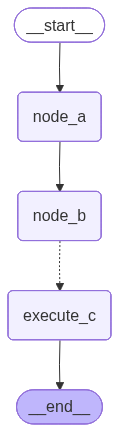

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config: RunnableConfig = {"configurable": {"thread_id": "1"}}


interrupted_result = graph.invoke({"a_context": "Start"}, config)

In [ ]:
async for event in graph.astream_events({"a_context": "Start"}, config):
    event_name = event["event"]
    name = event["name"]
    node = event.get("metadata", {}).get("langgraph_node", "")

    print(node)
final_state = graph.get_state(config)
print("Final state:", final_state)



--- Event ---
{'event': 'on_chain_start', 'data': {'input': {'a_context': 'Start'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019dc0d2-8d45-7863-8d75-6e2cd393570a', 'metadata': {'thread_id': '1'}, 'parent_ids': []}

--- Event ---
{'event': 'on_chain_start', 'data': {'input': {'a_context': 'Start', 'b_context': 'Result from A', 'b_result': ['Result 1 from B', 'Result 2 from B'], 'c_results': ['Result from C (iteration=1)', 'Result from C (iteration=2)']}}, 'name': 'node_a', 'tags': ['graph:step:6'], 'run_id': '019dc0d2-8d48-76d3-9fa3-75f9416aba9b', 'metadata': {'thread_id': '1', 'langgraph_step': 6, 'langgraph_node': 'node_a', 'langgraph_triggers': ('branch:to:node_a',), 'langgraph_path': ('__pregel_pull', 'node_a'), 'langgraph_checkpoint_ns': 'node_a:88f7ddd6-89e0-1eed-4e64-331b62f3f9c1'}, 'parent_ids': ['019dc0d2-8d45-7863-8d75-6e2cd393570a']}


----------------------
Node A
State: {'a_context': 'Start', 'b_context': 'Result from A', 'b_result': ['Result 1 from B', 'Result 2 from 

In [8]:
interrupts = interrupted_result["__interrupt__"]
resume_map = {
    interrupts[0].id: {"approved": 1},  # branch 1 approved
    interrupts[1].id: {"approved": 0},  # branch 2 rejected, loop back
}

result = graph.invoke(Command(resume=resume_map), config)
print(result)


execute_c called with context : 'Result 1 from B'

--- Node C Review ---
    reviewed  : Result from C (iteration=1)
    waiting for human feedback...
    feedback received: {'approved': 1}
    ✅ Approved on iteration 1

→ Routing to END

execute_c called with context : 'Result 2 from B'

--- Node C Review ---
    reviewed  : Result from C (iteration=1)
    waiting for human feedback...
    feedback received: {'approved': 0}
    🔁 Rejected on iteration 1, looping back

→ Routing back to node_c

--- Node C ---
    iteration : 2
    produced  : Result from C (iteration=2)

  ✅ subgraph done
     final c_result : Result from C (iteration=1)
     total messages : 2
       • [node_c iter=1] Result from C (iteration=1)
       • [review iter=1] Approved — Result from C (iteration=1)

--- Node C Review ---
    reviewed  : Result from C (iteration=2)
    waiting for human feedback...
{'a_context': 'Start', 'b_context': 'Result from A', 'b_result': ['Result 1 from B', 'Result 2 from B'], 'c_res

In [9]:
interrupts = result["__interrupt__"]
resume_map = {
    interrupts[0].id: {"approved": 1},  # branch 1 approved
}

result = graph.invoke(Command(resume=resume_map), config)
print(result)


execute_c called with context : 'Result 2 from B'

--- Node C Review ---
    reviewed  : Result from C (iteration=2)
    waiting for human feedback...
    feedback received: {'approved': 1}
    ✅ Approved on iteration 2

→ Routing to END

  ✅ subgraph done
     final c_result : Result from C (iteration=2)
     total messages : 4
       • [node_c iter=1] Result from C (iteration=1)
       • [review iter=1] Rejected — looping back
       • [node_c iter=2] Result from C (iteration=2)
       • [review iter=2] Approved — Result from C (iteration=2)
{'a_context': 'Start', 'b_context': 'Result from A', 'b_result': ['Result 1 from B', 'Result 2 from B'], 'c_results': ['Result from C (iteration=1)', 'Result from C (iteration=2)']}
